# Animal depiction annotation: label proportions by category

Reads `7k_animal_depiction_annotation_04302026.csv` and summarizes, per category, the fraction of rows labeled **skip**, **real-life** (`yes`), and **not real-life** (`no`).

Also reports **P(not real-life | not skip)** — among rows that are not `skip`, the fraction labeled not real-life (complements **P(real-life | not skip)** over the same non-skip set).

At the end, builds **per-category image montages** for **not real-life** exemplars (`label=no`) from BV crops, plus **one combined figure** (4 + 3 layout).

In [7]:
from pathlib import Path

import pandas as pd

# Project root: parent of analysis/manuscript-2026
PROJECT_ROOT = Path.cwd().resolve().parents[1]
ANNOTATION_CSV = (
    PROJECT_ROOT
    / "annotation"
    / "annotation_data"
    / "7k_animal_depiction_annotation_04302026.csv"
)

df = pd.read_csv(ANNOTATION_CSV)
assert set(df.columns) >= {"category", "label"}

LABEL_MAP = {
    "yes": "real-life",
    "no": "not real-life",
    "skip": "skip",
}
unknown = set(df["label"].unique()) - set(LABEL_MAP)
if unknown:
    raise ValueError(f"Unexpected label values: {unknown}")

df["label_display"] = df["label"].map(LABEL_MAP)

PREPRINT_DIR = PROJECT_ROOT / "analysis" / "manuscript-2026"
RUN_ROOT = PREPRINT_DIR / "supplemental_results_valid85cats_04302026"
RESULTS_DIR = RUN_ROOT / "results"
FIGURES_DIR = RUN_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df.head()

,category,filename,relative_path,label,label_display
0,alligator,alligator_0.270_00430001_2023-08-23_1_c1a4695a...,alligator/alligator_0.270_00430001_2023-08-23_...,skip,skip
1,alligator,alligator_0.272_00370001_2024-08-24_1_6ef6f212...,alligator/alligator_0.272_00370001_2024-08-24_...,skip,skip
2,alligator,alligator_0.274_00400003_2023-12-17_2_f7d8a033...,alligator/alligator_0.274_00400003_2023-12-17_...,no,not real-life
3,alligator,alligator_0.275_00500001_2024-10-04_1_ca5ed548...,alligator/alligator_0.275_00500001_2024-10-04_...,skip,skip
4,alligator,alligator_0.276_00430001_2023-12-16_2_0636765b...,alligator/alligator_0.276_00430001_2023-12-16_...,skip,skip


In [8]:
# Counts and proportions per category (rows sum to 1.0 per category)
order = ["skip", "real-life", "not real-life"]
counts = (
    df.groupby(["category", "label_display"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=order, fill_value=0)
)
totals = counts.sum(axis=1)
props = counts.div(totals, axis=0)

summary = counts.copy()
summary.columns = [f"n_{c}" for c in summary.columns]
for c in order:
    summary[f"p_{c}"] = props[c]
summary["n_total"] = totals
summary = summary.sort_index()

summary_path = RESULTS_DIR / "animal_depiction_label_proportions_by_category.csv"
summary.to_csv(summary_path, index_label="category")
print(f"Saved: {summary_path}")

summary.round({c: 4 for c in summary.columns if c.startswith("p_")})

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/results/animal_depiction_label_proportions_by_category.csv


,n_skip,n_real-life,n_not real-life,p_skip,p_real-life,p_not real-life,n_total
category,,,,,,,
alligator,61,0,39,0.61,0.00,0.39,100
bird,49,3,48,0.49,0.03,0.48,100
butterfly,9,2,89,0.09,0.02,0.89,100
cat,40,57,3,0.40,0.57,0.03,100
dog,29,55,16,0.29,0.55,0.16,100
frog,72,1,27,0.72,0.01,0.27,100
pony,33,0,67,0.33,0.00,0.67,100


In [9]:
# Among non-skip rows only: P(not real-life) and P(real-life) (they sum to 1 per category)
non_skip = df[df["label_display"] != "skip"]
order_ns = ["real-life", "not real-life"]
counts_ns = (
    non_skip.groupby(["category", "label_display"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=order_ns, fill_value=0)
)
n_non_skip = counts_ns.sum(axis=1)
p_not_given_non_skip = counts_ns["not real-life"] / n_non_skip
p_real_given_non_skip = counts_ns["real-life"] / n_non_skip

cond_non_skip = pd.DataFrame(
    {
        "n_non_skip": n_non_skip.astype(int),
        "n_real-life": counts_ns["real-life"].astype(int),
        "n_not real-life": counts_ns["not real-life"].astype(int),
        "p_not real-life | not skip": p_not_given_non_skip,
        "p_real-life | not skip": p_real_given_non_skip,
    }
).sort_index()

cond_path = RESULTS_DIR / "animal_depiction_conditional_non_skip_by_category.csv"
cond_non_skip.to_csv(cond_path, index_label="category")
print(f"Saved: {cond_path}")

cond_non_skip.round(
    {c: 4 for c in cond_non_skip.columns if c.startswith("p_")}
)

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/results/animal_depiction_conditional_non_skip_by_category.csv


,n_non_skip,n_real-life,n_not real-life,p_not real-life | not skip,p_real-life | not skip
category,,,,,
alligator,39,0,39,1.0000,0.0000
bird,51,3,48,0.9412,0.0588
butterfly,91,2,89,0.9780,0.0220
cat,60,57,3,0.0500,0.9500
dog,71,55,16,0.2254,0.7746
frog,28,1,27,0.9643,0.0357
pony,67,0,67,1.0000,0.0000


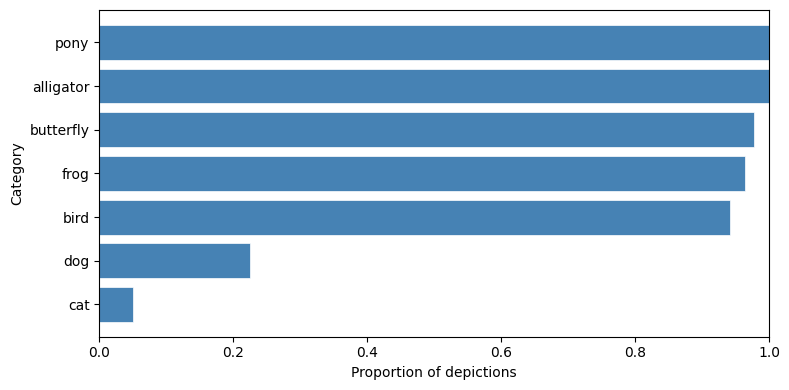

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/figures/animal_depiction_p_not_real_life_given_non_skip_by_category.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/figures/animal_depiction_p_not_real_life_given_non_skip_by_category.pdf


In [10]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]

col = "p_not real-life | not skip"
s = cond_non_skip[col].dropna().sort_values(ascending=True)
fig_h = max(4.0, 0.45 * len(s))
fig, ax = plt.subplots(figsize=(8, fig_h))
ax.barh(s.index.astype(str), s.values, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Proportion of depictions")
ax.set_ylabel("Category")
ax.set_xlim(0, 1)
fig.tight_layout()

out_path = FIGURES_DIR / "animal_depiction_p_not_real_life_given_non_skip_by_category.png"
out_pdf = out_path.with_suffix(".pdf")
fig.savefig(out_path, dpi=200, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print(f"Saved: {out_pdf}")

In [11]:
# Overall proportions (all rows)
overall = df["label_display"].value_counts(normalize=True).reindex(order).fillna(0)
overall_n = df["label_display"].value_counts().reindex(order).fillna(0).astype(int)
overall_df = pd.DataFrame({"n": overall_n, "proportion": overall})

overall_path = RESULTS_DIR / "animal_depiction_label_overall.csv"
overall_df.to_csv(overall_path, index_label="label_display")
print(f"Saved: {overall_path}")

overall_df

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/results/animal_depiction_label_overall.csv


,n,proportion
label_display,,
skip,293,0.418571
real-life,118,0.168571
not real-life,289,0.412857


## Not real-life exemplar montages

One PNG montage **per category** for rows labeled `no` (not real-life). Paths are **`CROPPED_DIR / relative_path`**. Exemplars are subsampled up to **`n_per_montage`**, balancing across `(subject_id, video)` inferred from each filename stem when possible (same idea as `analysis/vss-2026/make_animal_category_montages.py`).

The cell after that stitches the montages into **`not_real_life_depiction_montages_combined.png`** (and **`.pdf`**): four categories in the top row and three centered in the second row (alphabetical order).

In [12]:
import random
import re
from collections import defaultdict

import numpy as np
from PIL import Image

# BV crop root (same as analysis/vss-2026/make_animal_category_montages.py); edit if needed
CROPPED_DIR = Path("/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_all_cropped_by_class")
MONTAGE_SUBDIR = FIGURES_DIR / "not_real_life_depiction_montages"
MONTAGE_SUBDIR.mkdir(parents=True, exist_ok=True)

STEM_PATTERN = re.compile(r"^(.+?)_([\d.]+)_(\d+)_(.+?)_processed_(\d+)$")


def _source_key_from_stem(stem: str):
    m = STEM_PATTERN.match(stem)
    if m:
        return (m.group(3), m.group(4))
    return (stem, stem)


def _sample_paths_diversified(paths: list, n: int, seed=None):
    if seed is not None:
        random.seed(seed)
    if len(paths) <= n:
        return list(paths)
    groups = defaultdict(list)
    for p in paths:
        groups[_source_key_from_stem(p.stem)].append(p)
    keys = list(groups.keys())
    random.shuffle(keys)
    chosen = []
    for k in keys:
        if len(chosen) >= n:
            break
        pool = groups[k]
        random.shuffle(pool)
        chosen.append(pool[0])
    if len(chosen) < n:
        rem = [p for p in paths if p not in chosen]
        random.shuffle(rem)
        chosen.extend(rem[: n - len(chosen)])
    random.shuffle(chosen)
    return chosen


def _make_montage(paths: list, cell_size: tuple, n_cols: int):
    if not paths:
        return None
    n = len(paths)
    n_rows = (n + n_cols - 1) // n_cols
    out = Image.new("RGB", (n_cols * cell_size[0], n_rows * cell_size[1]), (240, 240, 240))
    for idx, p in enumerate(paths):
        try:
            img = Image.open(p).convert("RGB")
            if img.size != cell_size:
                img = img.resize(cell_size, Image.Resampling.LANCZOS)
            r, c = idx // n_cols, idx % n_cols
            out.paste(img, (c * cell_size[0], r * cell_size[1]))
        except OSError:
            pass
    return out


if not {"relative_path", "category"}.issubset(df.columns):
    raise ValueError("df must include relative_path and category (run earlier cells first).")

not_rl = df[df["label"].astype(str).str.lower() == "no"].copy()
n_per_montage = 25
cell_sz = (128, 128)
base_seed = 42
n_cols_base = int(np.ceil(np.sqrt(n_per_montage)))

if not CROPPED_DIR.is_dir():
    print(f"Skip montages: cropped dir not found: {CROPPED_DIR}")
elif not_rl.empty:
    print("No rows labeled 'no'.")
else:
    by_cat = defaultdict(list)
    for _, row in not_rl.iterrows():
        p = CROPPED_DIR / str(row["relative_path"]).strip()
        by_cat[str(row["category"]).strip().lower()].append(p)

    for cat in sorted(by_cat.keys()):
        candidates = sorted({p for p in by_cat[cat] if p.is_file()}, key=lambda x: x.name)
        if not candidates:
            print(f"  {cat}: skip (0 files on disk)")
            continue
        cat_seed = base_seed + sum(ord(c) for c in cat)
        sampled = _sample_paths_diversified(candidates, n_per_montage, seed=cat_seed)
        use_cols = min(n_cols_base, len(sampled))
        montage = _make_montage(sampled, cell_sz, max(use_cols, 1))
        if montage is None:
            print(f"  {cat}: skip (montage failed)")
            continue
        outp = MONTAGE_SUBDIR / f"{cat}_not_real_life_montage.png"
        montage.save(outp)
        print(f"  {cat}: saved {outp.name} ({len(sampled)} in montage / {len(candidates)} labeled)")
    print(f"Montages under {MONTAGE_SUBDIR.resolve()}")

  alligator: saved alligator_not_real_life_montage.png (25 in montage / 39 labeled)
  bird: saved bird_not_real_life_montage.png (25 in montage / 48 labeled)
  butterfly: saved butterfly_not_real_life_montage.png (25 in montage / 89 labeled)
  cat: saved cat_not_real_life_montage.png (3 in montage / 3 labeled)
  dog: saved dog_not_real_life_montage.png (16 in montage / 16 labeled)
  frog: saved frog_not_real_life_montage.png (25 in montage / 27 labeled)
  pony: saved pony_not_real_life_montage.png (25 in montage / 67 labeled)
Montages under /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/figures/not_real_life_depiction_montages


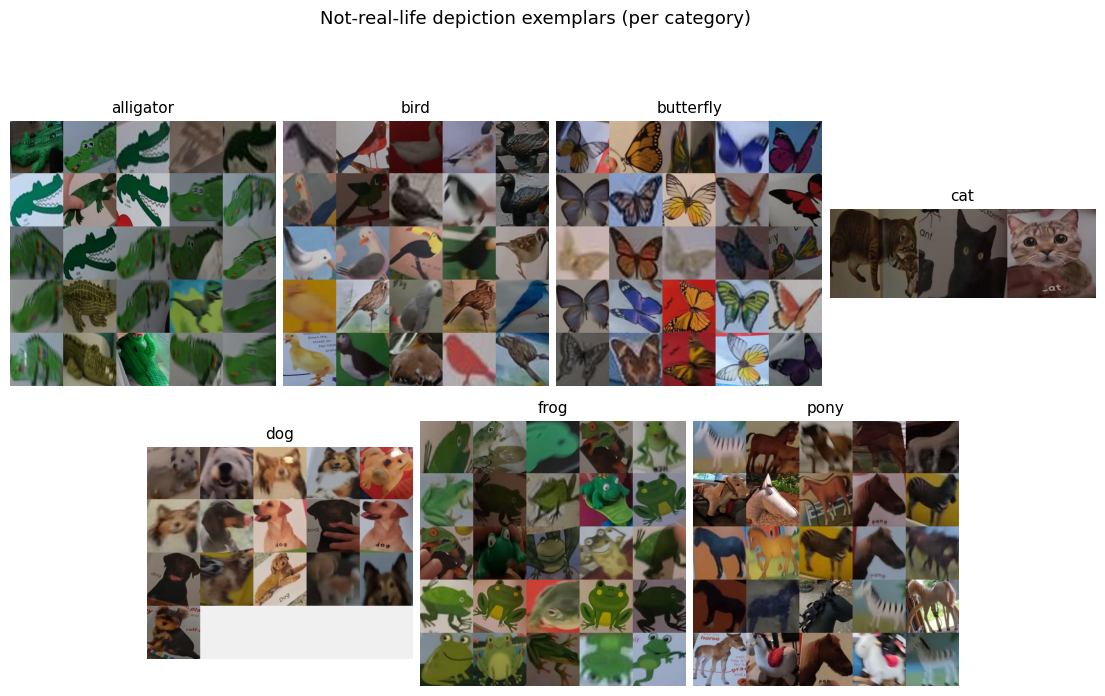

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/figures/not_real_life_depiction_montages_combined.png
Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/manuscript-2026/supplemental_results_valid85cats_04302026/figures/not_real_life_depiction_montages_combined.pdf


In [13]:
# Combined layout: 4 categories (top row) + 3 centered (bottom); alphabetical category order.
import matplotlib.pyplot as plt
from matplotlib import gridspec

montage_pngs = sorted(MONTAGE_SUBDIR.glob("*_not_real_life_montage.png"))
if not montage_pngs:
    print(f"No PNGs found in {MONTAGE_SUBDIR} (run the montage cell first).")
else:
    cats_ordered = sorted(
        p.name.replace("_not_real_life_montage.png", "") for p in montage_pngs
    )
    if len(cats_ordered) != 7:
        print(
            f"Combined 4+3 figure skipped: need 7 PNGs, got {len(cats_ordered)}: {cats_ordered}"
        )
    else:
        imgs = [
            Image.open(MONTAGE_SUBDIR / f"{c}_not_real_life_montage.png").convert("RGB")
            for c in cats_ordered
        ]

        fig = plt.figure(figsize=(14, 7.5))
        gs = gridspec.GridSpec(2, 8, figure=fig, height_ratios=[1, 1], hspace=0.08, wspace=0.06)

        for i in range(4):
            ax = fig.add_subplot(gs[0, 2 * i : 2 * i + 2])
            ax.imshow(np.asarray(imgs[i]))
            ax.set_title(cats_ordered[i], fontsize=11)
            ax.axis("off")

        for lab, im, span in zip(
            cats_ordered[4:7],
            imgs[4:7],
            [(1, 3), (3, 5), (5, 7)],
        ):
            ax = fig.add_subplot(gs[1, span[0] : span[1]])
            ax.imshow(np.asarray(im))
            ax.set_title(lab, fontsize=11)
            ax.axis("off")

        fig.suptitle("Not-real-life depiction exemplars (per category)", fontsize=13, y=1.02)
        combined_png = FIGURES_DIR / "not_real_life_depiction_montages_combined.png"
        combined_pdf = combined_png.with_suffix(".pdf")
        fig.savefig(combined_png, dpi=200, bbox_inches="tight")
        fig.savefig(combined_pdf, bbox_inches="tight")
        plt.show()
        print(f"Saved: {combined_png}")
        print(f"Saved: {combined_pdf}")